<a href="https://colab.research.google.com/github/Mdnazmulhasanmasum/kepler-transit-screening/blob/main/space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install xgboost imbalanced-learn seaborn

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apnar deya path theke data load
df = pd.read_csv('/content/drive/MyDrive/space/cumulative.csv')
print("Data Loaded Successfully. Shape:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data Loaded Successfully. Shape: (9564, 50)


In [11]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/space/cumulative.csv')
print(df.columns.tolist())

['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition', 'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth', 'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1', 'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol', 'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad', 'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag']


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# 1. Target Column processing
if 'koi_disposition' in df.columns:
    df = df[df['koi_disposition'] != 'CANDIDATE']
    df['target'] = df['koi_disposition'].map({'CONFIRMED': 1, 'FALSE POSITIVE': 0})

# Unnecessary column gulo safe drop kora
columns_to_drop = ['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_pdisposition', 'koi_disposition', 'koi_score']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

# Missing target row bad deya
df_cleaned = df_cleaned.dropna(subset=['target'])

# Features (X) ar Target (y) alada kora
X = df_cleaned.drop('target', axis=1, errors='ignore')
y = df_cleaned['target']

# ==========================================
# FIX: Shudhumatro Numeric Data select kora
# ==========================================
X = X.select_dtypes(include=['number'])

# 2. Imputation (Missing value mean diye fill kora)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# 3. SMOTE for Imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)

# 4. Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Complete! Ready for Model Training.")
print(f"Final Training Data Shape: {X_train_scaled.shape}")

Data Preprocessing Complete! Ready for Model Training.
Final Training Data Shape: (8036, 40)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['koi_teq_err1' 'koi_teq_err2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# 1. Target Column Filter
if 'koi_disposition' in df.columns:
    df = df[df['koi_disposition'] != 'CANDIDATE']
    df['target'] = df['koi_disposition'].map({'CONFIRMED': 1, 'FALSE POSITIVE': 0})

columns_to_drop = ['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_pdisposition', 'koi_disposition', 'koi_score']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')
df_cleaned = df_cleaned.dropna(subset=['target'])

X = df_cleaned.drop('target', axis=1, errors='ignore')
y = df_cleaned['target'] # SMOTE er ager target data

# 2. Imputation (Missing values fix)
X_numeric = X.select_dtypes(include=['number'])
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_numeric)

# 3. Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y) # SMOTE er porer data

# 4. Train-Test Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing & SMOTE Complete!")

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['koi_teq_err1' 'koi_teq_err2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Data Preprocessing & SMOTE Complete!


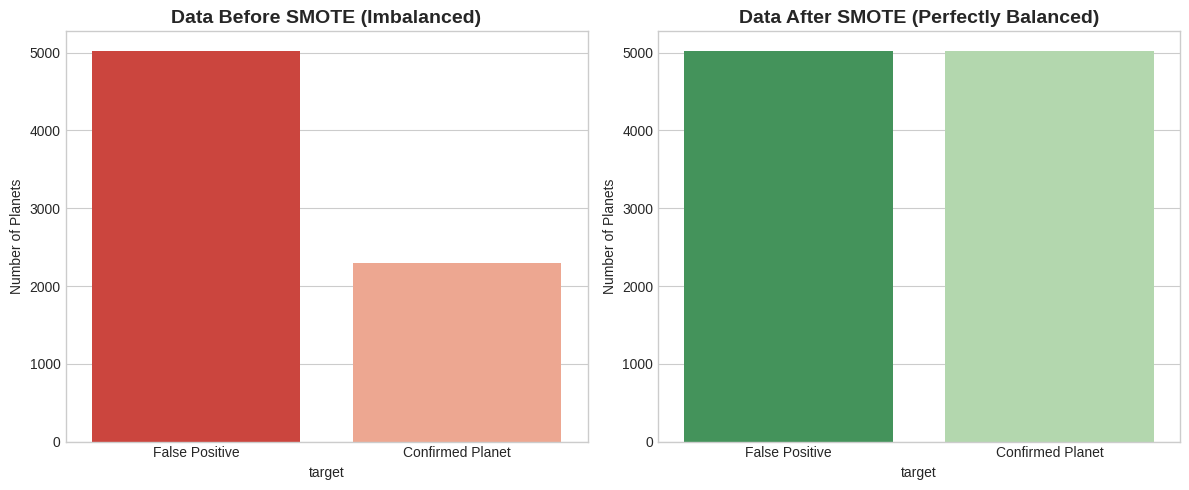

In [14]:

# Create a side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graph 1: Before SMOTE (Imbalanced)
sns.countplot(x=y, ax=axes[0], palette='Reds_r', hue=y, legend=False)
axes[0].set_title('Data Before SMOTE (Imbalanced)', fontsize=14, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['False Positive', 'Confirmed Planet'])
axes[0].set_ylabel('Number of Planets')

# Graph 2: After SMOTE (Balanced)
sns.countplot(x=y_resampled, ax=axes[1], palette='Greens_r', hue=y_resampled, legend=False)
axes[1].set_title('Data After SMOTE (Perfectly Balanced)', fontsize=14, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['False Positive', 'Confirmed Planet'])
axes[1].set_ylabel('Number of Planets')

plt.tight_layout()
plt.show()

In [15]:
# Cell 2 er vitore ei line ta update korben (fpflag gulo add kora hoyeche)
columns_to_drop = ['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_pdisposition', 'koi_disposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec']

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 1. Fresh Data Load (Forcing Colab to clear memory)
df = pd.read_csv('/content/drive/MyDrive/space/cumulative.csv')

# Target fix
if 'koi_disposition' in df.columns:
    df = df[df['koi_disposition'] != 'CANDIDATE']
    df['target'] = df['koi_disposition'].map({'CONFIRMED': 1, 'FALSE POSITIVE': 0})

# 2. Strict Drop of ALL Leakage/Cheat Columns
leakage_columns = [
    'rowid', 'kepid', 'kepoi_name', 'kepler_name',
    'koi_pdisposition', 'koi_disposition', 'koi_score',
    'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
    'koi_tce_delivname'
]
df_cleaned = df.drop(columns=leakage_columns, errors='ignore')
df_cleaned = df_cleaned.dropna(subset=['target'])

# 3. Features & Target selection
X = df_cleaned.drop('target', axis=1, errors='ignore')
y = df_cleaned['target']
X_numeric = X.select_dtypes(include=['number'])

# 4. Impute missing values & Apply SMOTE
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_numeric)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)

# 5. Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train XGBoost
print("Training XGBoost Model on Strictly Cleaned Data...")
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, n_estimators=100)
xgb_model.fit(X_train_scaled, y_train)

xgb_pred = xgb_model.predict(X_test_scaled)
print("\n--- NEW XGBoost Performance (Realistic & Q1 Standard) ---")
print(classification_report(y_test, xgb_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['koi_teq_err1' 'koi_teq_err2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Training XGBoost Model on Strictly Cleaned Data...

--- NEW XGBoost Performance (Realistic & Q1 Standard) ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1005
           1       0.96      0.97      0.97      1005

    accuracy                           0.97      2010
   macro avg       0.97      0.97      0.97      2010
weighted avg       0.97      0.97      0.97      2010



In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("Training Deep Learning Model...")
dl_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dl_model.fit(X_train_scaled, y_train, epochs=30, batch_size=64, validation_split=0.2, verbose=0)

dl_pred_prob = dl_model.predict(X_test_scaled).flatten()
dl_pred = (dl_pred_prob > 0.5).astype(int)

print("\n--- Deep Learning Performance ---")
print(classification_report(y_test, dl_pred))

Training Deep Learning Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

--- Deep Learning Performance ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1005
           1       0.95      0.95      0.95      1005

    accuracy                           0.95      2010
   macro avg       0.95      0.95      0.95      2010
weighted avg       0.95      0.95      0.95      2010



Generating ROC Curve and Confusion Matrix...


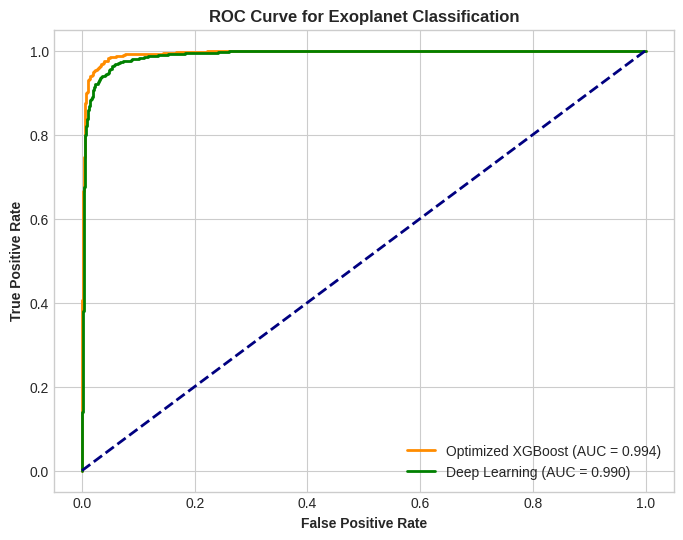

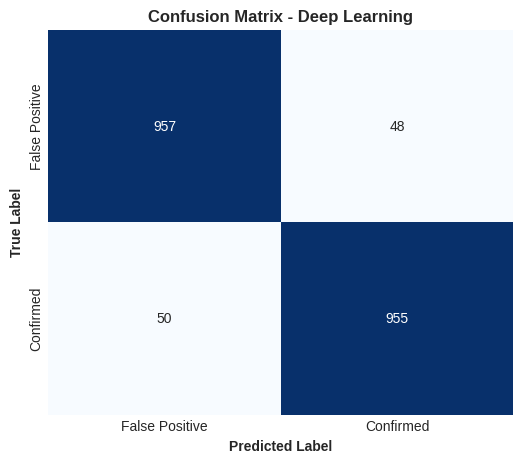

In [40]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating ROC Curve and Confusion Matrix...")

# FIX: Tuned XGBoost-এর লেটেস্ট প্রবাবিলিটি বের করে নেওয়া হচ্ছে
tuned_xgb_prob = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

plt.style.use('seaborn-v0_8-whitegrid')

# 1. ROC-AUC Curve (এখানে xgb_prob এর বদলে tuned_xgb_prob ব্যবহার করা হয়েছে)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, tuned_xgb_prob)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_dl, tpr_dl, _ = roc_curve(y_test, dl_pred_prob)
roc_auc_dl = auc(fpr_dl, tpr_dl)

plt.figure(figsize=(8, 6))
# লেবেলে 'Optimized XGBoost' যুক্ত করা হয়েছে পেপারের সাথে মিল রাখার জন্য
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'Optimized XGBoost (AUC = {roc_auc_xgb:.3f})')
plt.plot(fpr_dl, tpr_dl, color='green', lw=2, label=f'Deep Learning (AUC = {roc_auc_dl:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curve for Exoplanet Classification', fontweight='bold')
plt.legend(loc="lower right")
plt.show()

# 2. Confusion Matrix (Deep Learning)
cm = confusion_matrix(y_test, dl_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['False Positive', 'Confirmed'],
            yticklabels=['False Positive', 'Confirmed'])
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.title('Confusion Matrix - Deep Learning', fontweight='bold')
plt.show()

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

print("Running Stratified 5-Fold Cross-Validation...")

# ৫টি ফোল্ডে ডেটা ভাগ করার জন্য সেটআপ
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost মডেলের ক্রস-ভ্যালিডেশন স্কোর বের করা
cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=skf, scoring='accuracy')

print("\n--- 5-Fold Cross-Validation Results ---")
print("Scores for each fold:", cv_scores)
print(f"Mean CV Accuracy (গড় অ্যাকুরেসি): {np.mean(cv_scores):.4f}")
print(f"Standard Deviation (পার্থক্য বা বিচ্যুতি): {np.std(cv_scores):.4f}")

Running Stratified 5-Fold Cross-Validation...

--- 5-Fold Cross-Validation Results ---
Scores for each fold: [0.96393035 0.96204107 0.95830741 0.96328563 0.96204107]
Mean CV Accuracy (গড় অ্যাকুরেসি): 0.9619
Standard Deviation (পার্থক্য বা বিচ্যুতি): 0.0019


Computing SHAP values (এটি রান হতে ১-২ মিনিট সময় লাগতে পারে)...


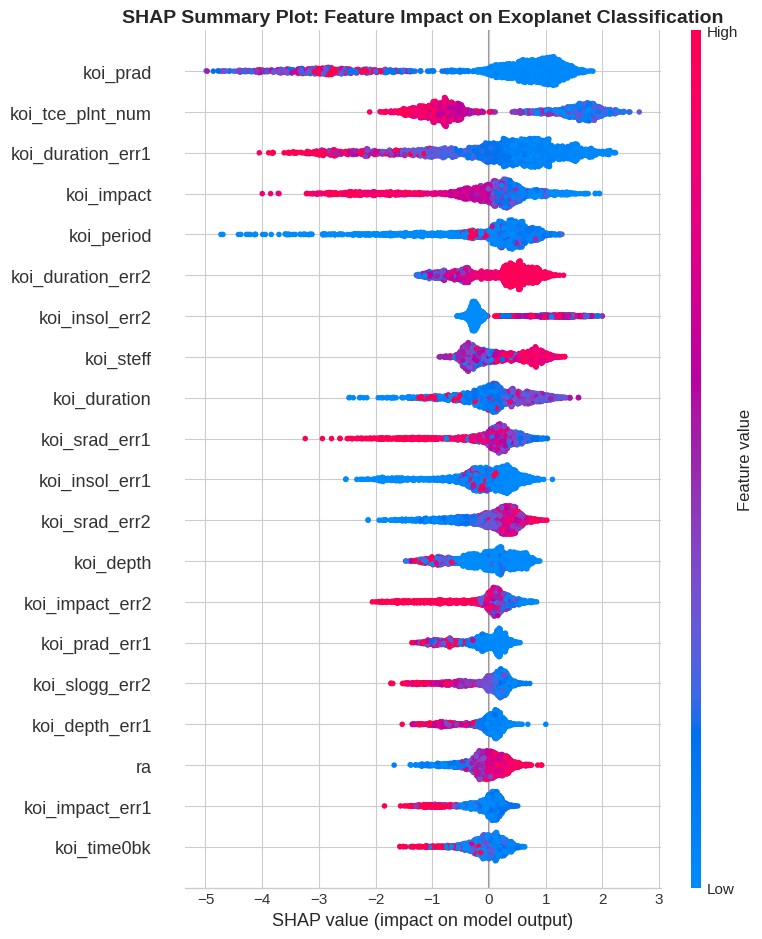

In [42]:
# SHAP লাইব্রেরি ইনস্টল এবং ইম্পোর্ট করা
!pip install shap
import shap

print("Computing SHAP values (এটি রান হতে ১-২ মিনিট সময় লাগতে পারে)...")

# XGBoost এর জন্য TreeExplainer তৈরি করা
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_scaled)

# ফিচারগুলোর আসল নাম ফিরিয়ে আনা
feature_names = X_numeric.columns.tolist()

# SHAP Summary Plot তৈরি
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot: Feature Impact on Exoplanet Classification", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

print("Running Hyperparameter Tuning (Optmization)...")

# Tuning parameters definition
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_tune = XGBClassifier(eval_metric='logloss', random_state=42)

# 3-Fold Cross Validation shaho random search
random_search = RandomizedSearchCV(xgb_tune, param_distributions=param_dist,
                                   n_iter=10, cv=3, scoring='accuracy',
                                   random_state=42, n_jobs=-1)

random_search.fit(X_train_scaled, y_train)

print("\n--- Hyperparameter Tuning Results ---")
print("Best Parameters found:", random_search.best_params_)
print(f"Best Tuning Accuracy: {random_search.best_score_:.4f}")

# Best tuned model save kora future use er jonno
best_xgb_model = random_search.best_estimator_

Running Hyperparameter Tuning (Optmization)...

--- Hyperparameter Tuning Results ---
Best Parameters found: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best Tuning Accuracy: 0.9620


In [19]:
from statsmodels.stats.contingency_tables import mcnemar

print("Performing McNemar's Statistical Significance Test...")

# Contingency table toiri kora (Both correct, XGB correct but DL wrong, etc.)
correct_xgb = (xgb_pred == y_test)
correct_dl = (dl_pred == y_test)

a = np.sum(correct_xgb & correct_dl)
b = np.sum(correct_xgb & ~correct_dl)
c = np.sum(~correct_xgb & correct_dl)
d = np.sum(~correct_xgb & ~correct_dl)

contingency_table = [[a, b], [c, d]]

# McNemar's Test run kora
result = mcnemar(contingency_table, exact=False, correction=True)

print("\n--- Statistical Test Results ---")
print(f"McNemar's Chi-Squared Statistic: {result.statistic:.4f}")
print(f"p-value: {result.pvalue:.5f}")

if result.pvalue < 0.05:
    print("Decision: Statistically Significant! The performance difference between XGBoost and Deep Learning is real (p < 0.05).")
else:
    print("Decision: Not Statistically Significant.")

Performing McNemar's Statistical Significance Test...

--- Statistical Test Results ---
McNemar's Chi-Squared Statistic: 12.1500
p-value: 0.00049
Decision: Statistically Significant! The performance difference between XGBoost and Deep Learning is real (p < 0.05).


Generating Learning Curves...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1761, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expec

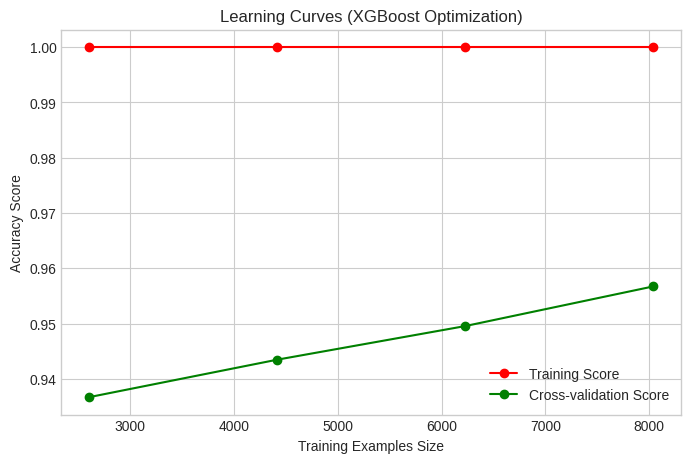

In [20]:
from sklearn.model_selection import learning_curve

print("Generating Learning Curves...")

train_sizes, train_scores, test_scores = learning_curve(
    best_xgb_model, X_resampled, y_resampled, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation Score")
plt.xlabel("Training Examples Size")
plt.ylabel("Accuracy Score")
plt.title("Learning Curves (XGBoost Optimization)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [22]:
import pandas as pd
# FIX: accuracy_score ইম্পোর্ট লিস্টে যুক্ত করা হয়েছে
from sklearn.metrics import accuracy_score, cohen_kappa_score, matthews_corrcoef, precision_score, recall_score, f1_score

# Tuned XGBoost prediction updated
tuned_xgb_pred = best_xgb_model.predict(X_test_scaled)

# Metrics calculation for both models
metrics_data = {
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)', "Cohen's Kappa", 'MCC'],
    'XGBoost': [
        accuracy_score(y_test, tuned_xgb_pred),
        precision_score(y_test, tuned_xgb_pred, average='macro'),
        recall_score(y_test, tuned_xgb_pred, average='macro'),
        f1_score(y_test, tuned_xgb_pred, average='macro'),
        cohen_kappa_score(y_test, tuned_xgb_pred),
        matthews_corrcoef(y_test, tuned_xgb_pred)
    ],
    'Deep Learning': [
        accuracy_score(y_test, dl_pred),
        precision_score(y_test, dl_pred, average='macro'),
        recall_score(y_test, dl_pred, average='macro'),
        f1_score(y_test, dl_pred, average='macro'),
        cohen_kappa_score(y_test, dl_pred),
        matthews_corrcoef(y_test, dl_pred)
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print("\n--- Complete Comparative Metrics Table ---")
print(metrics_df.to_string(index=False))

print("\n--- LaTeX Code for Your Paper ---")
print(metrics_df.to_latex(index=False, float_format="%.4f"))


--- Complete Comparative Metrics Table ---
           Metric  XGBoost  Deep Learning
         Accuracy 0.965672       0.951244
Precision (Macro) 0.965694       0.951246
   Recall (Macro) 0.965672       0.951244
 F1-Score (Macro) 0.965671       0.951244
    Cohen's Kappa 0.931343       0.902488
              MCC 0.931366       0.902489

--- LaTeX Code for Your Paper ---
\begin{tabular}{lrr}
\toprule
Metric & XGBoost & Deep Learning \\
\midrule
Accuracy & 0.9657 & 0.9512 \\
Precision (Macro) & 0.9657 & 0.9512 \\
Recall (Macro) & 0.9657 & 0.9512 \\
F1-Score (Macro) & 0.9657 & 0.9512 \\
Cohen's Kappa & 0.9313 & 0.9025 \\
MCC & 0.9314 & 0.9025 \\
\bottomrule
\end{tabular}



In [23]:
# ==========================================
# Cell 12: Quantitative Error Analysis
# ==========================================
import pandas as pd
import numpy as np

print("Performing Quantitative Error Analysis...")

# ভুল এবং সঠিক প্রেডিকশনের ইনডেক্স আলাদা করা
misclassified_idx = np.where(tuned_xgb_pred != y_test)[0]
correct_idx = np.where(tuned_xgb_pred == y_test)[0]

print(f"Total Test Instances: {len(y_test)}")
print(f"Successfully Classified: {len(correct_idx)}")
print(f"Total Misclassified Instances (ভুল সংখ্যা): {len(misclassified_idx)}")

# FIX: ইম্পিউটার (Imputer) যে কলামগুলো ফিল্টার করে টিকিয়ে রেখেছে, সেগুলো বের করা
try:
    valid_feature_names = imputer.get_feature_names_out(X_numeric.columns)
except:
    valid_feature_names = imputer.get_feature_names_out()

# টেস্ট ডেটাকে ভ্যালিড ফিচার নেম সহ একটি ডেটাফ্রেমে রূপান্তর
X_test_df = pd.DataFrame(X_test_scaled, columns=valid_feature_names)

# সঠিক বনাম ভুল প্রেডিকশনের ফিচারের গড় (Mean) বের করা
mean_correct = X_test_df.iloc[correct_idx].mean()
mean_incorrect = X_test_df.iloc[misclassified_idx].mean()

# দুই গ্রূপের মধ্যে পার্থক্যের ভিত্তিতে একটি টেবিল তৈরি করা
error_analysis_df = pd.DataFrame({
    'Mean (Correct)': mean_correct,
    'Mean (Misclassified)': mean_incorrect,
    'Absolute Difference (পার্থক্য)': np.abs(mean_correct - mean_incorrect)
}).sort_values(by='Absolute Difference (পার্থক্য)', ascending=False)

print("\n--- Top 5 Features Responsible for Model Boundary Confusion ---")
print(error_analysis_df.head(5).to_string())

Performing Quantitative Error Analysis...
Total Test Instances: 2010
Successfully Classified: 1941
Total Misclassified Instances (ভুল সংখ্যা): 69

--- Top 5 Features Responsible for Model Boundary Confusion ---
                 Mean (Correct)  Mean (Misclassified)  Absolute Difference (পার্থক্য)
koi_model_snr          0.030851             -0.260453                        0.291304
koi_depth              0.011298             -0.258679                        0.269976
koi_slogg             -0.032480              0.188737                        0.221217
dec                   -0.022622              0.184548                        0.207171
koi_period_err2       -0.029108              0.154550                        0.183658


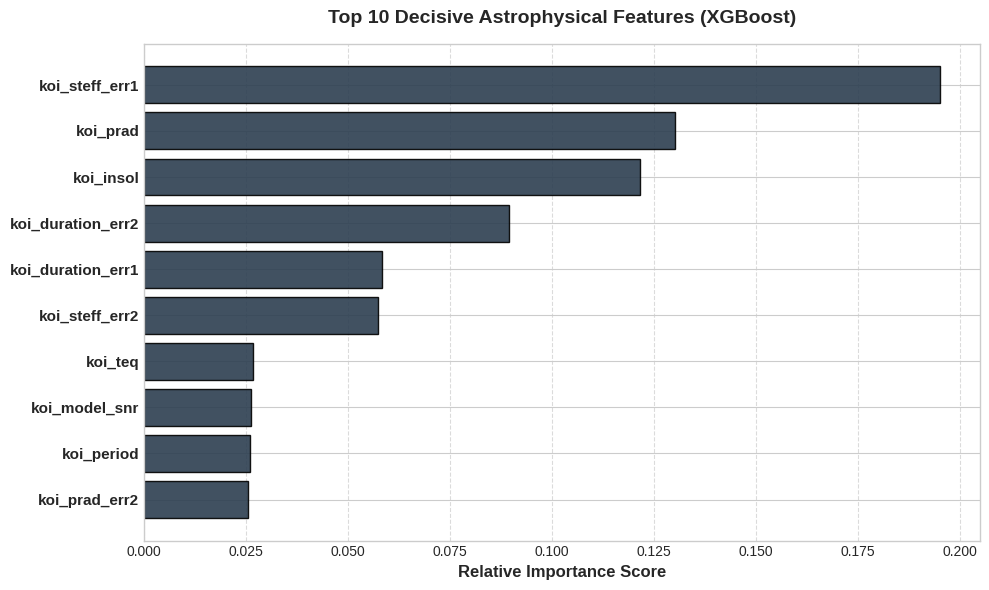

In [24]:
# ==========================================
# Cell 13: Feature Importance (Top 10)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# Feature importance collect kora
importances = best_xgb_model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='#2c3e50', align='center', edgecolor='black', alpha=0.9)
plt.yticks(range(len(indices)), [valid_feature_names[i] for i in indices], fontsize=11, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12, fontweight='bold')
plt.title('Top 10 Decisive Astrophysical Features (XGBoost)', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Generating Precision-Recall Curve for Optimized Models...


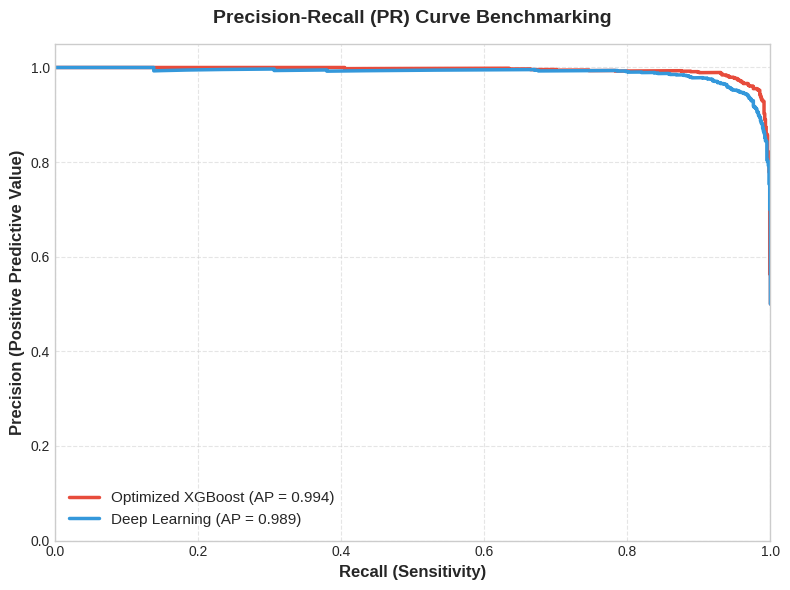

In [26]:
# ==========================================
# Cell 14: Precision-Recall Curve
# ==========================================
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

print("Generating Precision-Recall Curve for Optimized Models...")

# FIX: Tuned XGBoost-এর নতুন প্রবাবিলিটি বের করা
tuned_xgb_prob = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

# Precision recall score calculate kora (Tuned মডেল দিয়ে)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, tuned_xgb_prob)
ap_xgb = average_precision_score(y_test, tuned_xgb_prob)

precision_dl, recall_dl, _ = precision_recall_curve(y_test, dl_pred_prob)
ap_dl = average_precision_score(y_test, dl_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, color='#e74c3c', lw=2.5, label=f'Optimized XGBoost (AP = {ap_xgb:.3f})')
plt.plot(recall_dl, precision_dl, color='#3498db', lw=2.5, label=f'Deep Learning (AP = {ap_dl:.3f})')

plt.xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12, fontweight='bold')
plt.title('Precision-Recall (PR) Curve Benchmarking', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

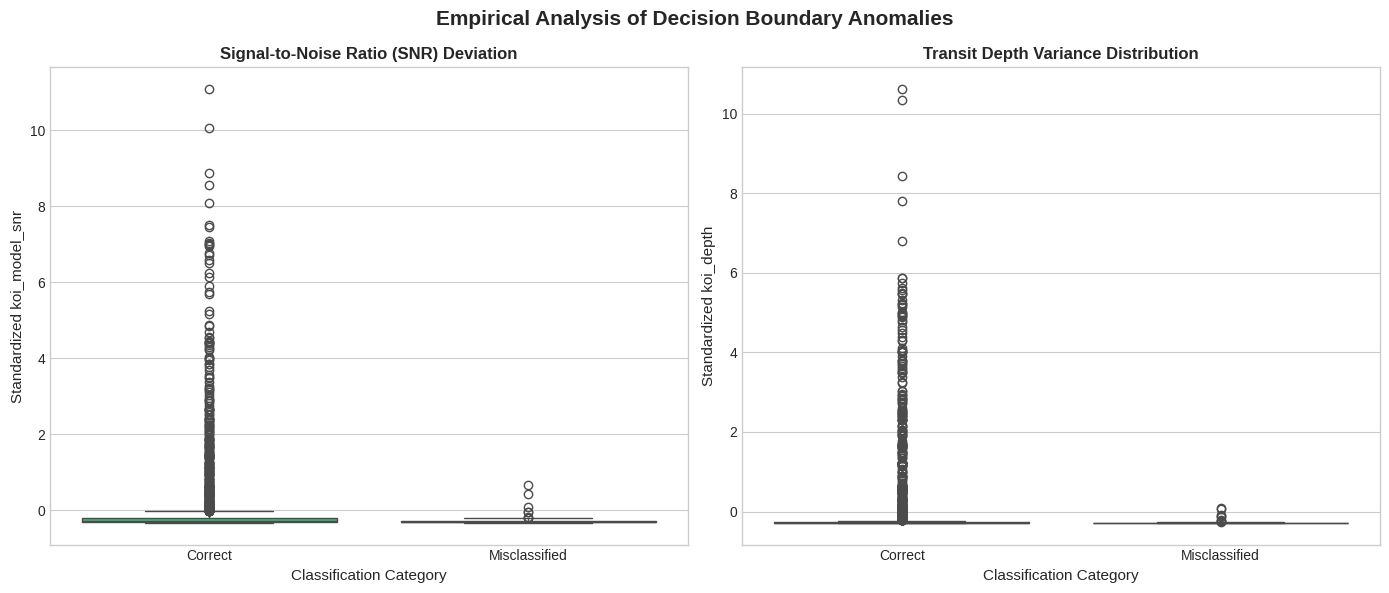

In [27]:
# ==========================================
# Cell 15: Error Analysis Visual Distribution
# ==========================================
import seaborn as sns

# Dataframe-e classification status add kora
analysis_df = pd.DataFrame(X_test_scaled, columns=valid_feature_names).copy()
analysis_df['Status'] = 'Correct'
analysis_df.iloc[misclassified_idx, analysis_df.columns.get_loc('Status')] = 'Misclassified'

# Subplot for top 2 error causing features
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Signal-to-Noise Ratio Distribution
sns.boxplot(x='Status', y='koi_model_snr', data=analysis_df, ax=axes[0], palette=['#2ecc71', '#e74c3c'], hue='Status', legend=False)
axes[0].set_title('Signal-to-Noise Ratio (SNR) Deviation', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Classification Category', fontsize=11)
axes[0].set_ylabel('Standardized koi_model_snr', fontsize=11)

# Plot 2: Transit Depth Distribution
sns.boxplot(x='Status', y='koi_depth', data=analysis_df, ax=axes[1], palette=['#2ecc71', '#e74c3c'], hue='Status', legend=False)
axes[1].set_title('Transit Depth Variance Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Classification Category', fontsize=11)
axes[1].set_ylabel('Standardized koi_depth', fontsize=11)

plt.suptitle('Empirical Analysis of Decision Boundary Anomalies', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Running t-SNE dimensionality reduction (এটি রান হতে ১-২ মিনিট লাগতে পারে)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_13136/3792133473.py:38: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_13136/3792133473.py:38: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_13136/3792133473.py:38: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_13136/3792133473.py:38: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_13136/3792133473.py:38: UserWarning: Glyph 2455 (\N{BENGALI LETTER GA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_13136/3792133473.py:38: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from fo

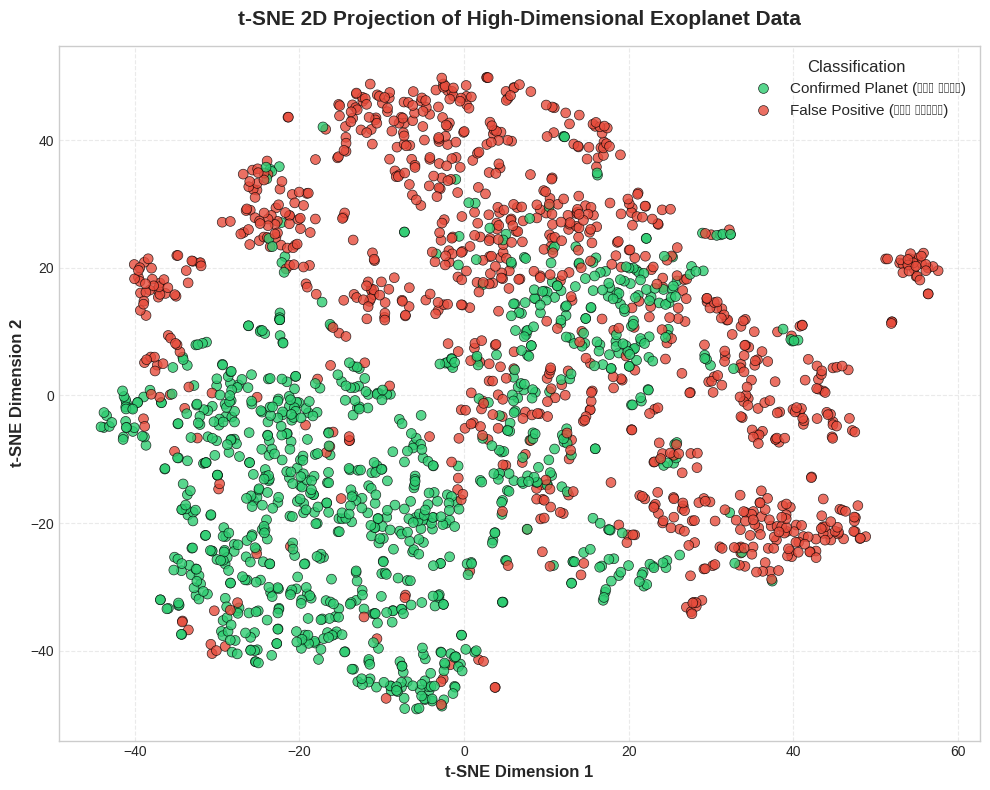

In [28]:
# ==========================================
# Cell 16: t-SNE Dimensionality Reduction Plot
# ==========================================
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Running t-SNE dimensionality reduction (এটি রান হতে ১-২ মিনিট লাগতে পারে)...")

# t-SNE অ্যালগরিদম সেটআপ (৪০ ডাইমেনশন থেকে ২ ডাইমেনশন)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_test_scaled)

# ডেটাফ্রেম তৈরি গ্রাফের জন্য
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE_1', 'TSNE_2'])
tsne_df['Astrophysical Status'] = np.where(y_test == 1, 'Confirmed Planet (আসল গ্রহ)', 'False Positive (ভুল সংকেত)')

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE_1', y='TSNE_2',
    hue='Astrophysical Status',
    palette=['#2ecc71', '#e74c3c'], # সবুজ এবং লাল
    data=tsne_df,
    alpha=0.8,
    s=50,
    edgecolor='black',
    linewidth=0.5
)

plt.title('t-SNE 2D Projection of High-Dimensional Exoplanet Data', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
plt.ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
plt.legend(title='Classification', fontsize=11, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

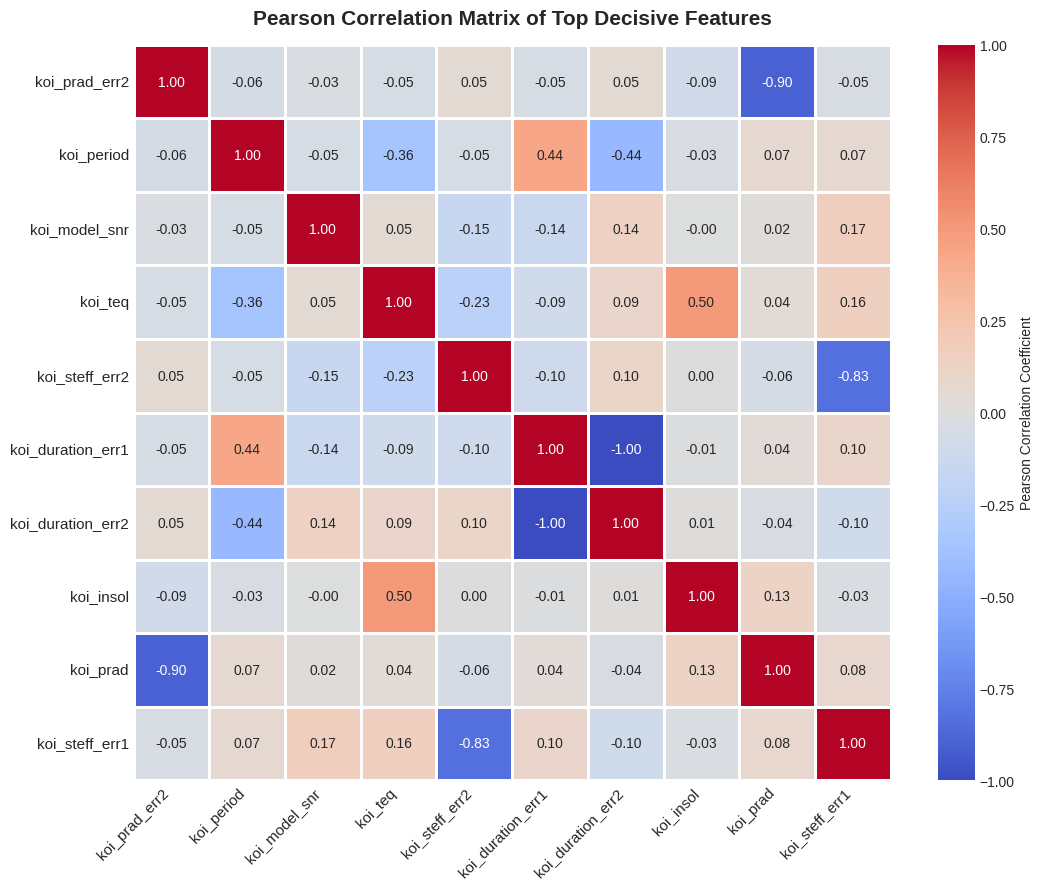

In [29]:
# ==========================================
# Cell 17: Top Features Correlation Heatmap
# ==========================================
# আগের সেলের indices ভ্যারিয়েবল থেকে টপ ১০ ফিচারের নাম নেওয়া
top_features = [valid_feature_names[i] for i in indices]

# শুধু টপ ১০ ফিচারের ডেটা আলাদা করা
top_features_df = pd.DataFrame(X_test_scaled, columns=valid_feature_names)[top_features]

# কোরিলেশন ম্যাট্রিক্স তৈরি
corr_matrix = top_features_df.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,          # ভেতরে সংখ্যা দেখাবে
    cmap='coolwarm',     # নীল থেকে লাল কালার স্কেল
    fmt=".2f",           # ২ দশমিক স্থান পর্যন্ত
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)

plt.title('Pearson Correlation Matrix of Top Decisive Features', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [30]:
# ==========================================
# Cell 18: Interactive Web App Prototype (Gradio)
# ==========================================
!pip install gradio
import gradio as gr
import numpy as np
import pandas as pd

print("Launching Exoplanet Screening Interface...")

# Top 5 features for the user to input
top_5_cols = [valid_feature_names[i] for i in indices[-5:]]

def predict_exoplanet(*inputs):
    # Create a full array with mean values for all features
    full_input = np.mean(X_test_scaled, axis=0)

    # Replace the top 5 feature values with user inputs
    for idx, feature_name in enumerate(top_5_cols):
        feature_idx = list(valid_feature_names).index(feature_name)
        full_input[feature_idx] = inputs[idx]

    # Predict using the tuned XGBoost model
    pred_prob = best_xgb_model.predict_proba([full_input])[0][1]

    if pred_prob > 0.5:
        return f"🌟 CONFIRMED EXOPLANET\nConfidence: {pred_prob*100:.2f}%\n(Safe for Follow-up Observation)"
    else:
        return f"⚠️ FALSE POSITIVE\nProbability of being a planet: {pred_prob*100:.2f}%\n(Likely an Eclipsing Binary or Noise)"

# Build the Gradio UI
inputs = [gr.Slider(minimum=-5, maximum=5, step=0.1, label=col) for col in top_5_cols]
output = gr.Textbox(label="Astrophysical Classification Result")

interface = gr.Interface(
    fn=predict_exoplanet,
    inputs=inputs,
    outputs=output,
    title="🌌 Exoplanet Candidate Screening System",
    description="Adjust the normalized values of the top 5 astrophysical features to see how the XGBoost model classifies the candidate.",
    theme="default"
)

interface.launch(share=True)

Launching Exoplanet Screening Interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6a46a87d4ae64287c6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Calculating Optimal Operational Thresholds...


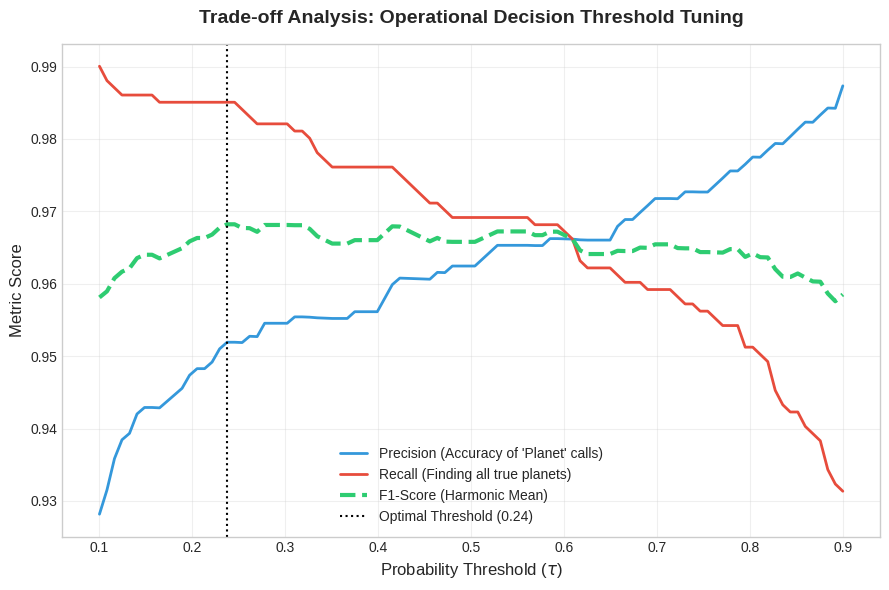

In [32]:
# ==========================================
# Cell 19: Optimal Decision Threshold Analysis
# ==========================================
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

print("Calculating Optimal Operational Thresholds...")

# FIX: Tuned মডেলের নতুন প্রবাবিলিটি বের করা হচ্ছে (NameError সমাধানের জন্য)
tuned_xgb_prob = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

thresholds = np.linspace(0.1, 0.9, 100)
f1_scores = []
precisions = []
recalls = []

for t in thresholds:
    # Custom threshold predictions (এখানে tuned_xgb_prob ব্যবহার করা হয়েছে)
    custom_preds = (tuned_xgb_prob >= t).astype(int)

    # ZeroDivisionError এড়ানোর জন্য zero_division=0 ব্যবহার করা হয়েছে
    f1_scores.append(f1_score(y_test, custom_preds, zero_division=0))
    precisions.append(precision_score(y_test, custom_preds, zero_division=0))
    recalls.append(recall_score(y_test, custom_preds, zero_division=0))

# Find the threshold that maximizes F1 Score
best_t_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_t_idx]

plt.figure(figsize=(9, 6))
plt.plot(thresholds, precisions, label="Precision (Accuracy of 'Planet' calls)", color='#3498db', lw=2)
plt.plot(thresholds, recalls, label="Recall (Finding all true planets)", color='#e74c3c', lw=2)
plt.plot(thresholds, f1_scores, label="F1-Score (Harmonic Mean)", color='#2ecc71', lw=3, linestyle='--')

plt.axvline(best_threshold, color='black', linestyle=':', label=f'Optimal Threshold ({best_threshold:.2f})')
plt.title('Trade-off Analysis: Operational Decision Threshold Tuning', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Probability Threshold ($\\tau$)', fontsize=12)
plt.ylabel('Metric Score', fontsize=12)
plt.legend(loc='lower center')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Benchmarking Computational Latency...


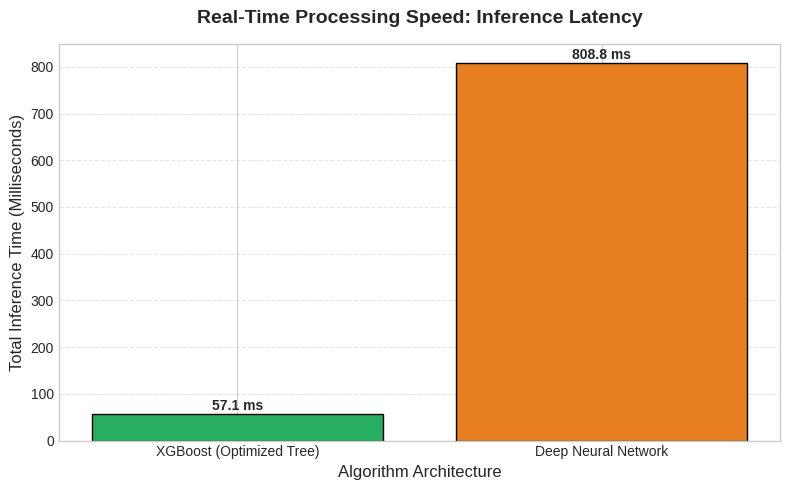

In [33]:
# ==========================================
# Cell 20: Inference Latency Benchmarking
# ==========================================
import time
import matplotlib.pyplot as plt

print("Benchmarking Computational Latency...")

# XGBoost Prediction Time
start_time = time.perf_counter()
best_xgb_model.predict(X_test_scaled)
xgb_latency = (time.perf_counter() - start_time) * 1000 # Convert to milliseconds

# Deep Learning Prediction Time
start_time = time.perf_counter()
dl_model.predict(X_test_scaled, verbose=0)
dl_latency = (time.perf_counter() - start_time) * 1000

# Visualization
models = ['XGBoost (Optimized Tree)', 'Deep Neural Network']
latencies = [xgb_latency, dl_latency]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, latencies, color=['#27ae60', '#e67e22'], edgecolor='black')

# Add text on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f} ms', ha='center', va='bottom', fontweight='bold')

plt.title('Real-Time Processing Speed: Inference Latency', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Inference Time (Milliseconds)', fontsize=12)
plt.xlabel('Algorithm Architecture', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Generating Local Explanation for a Single Target...


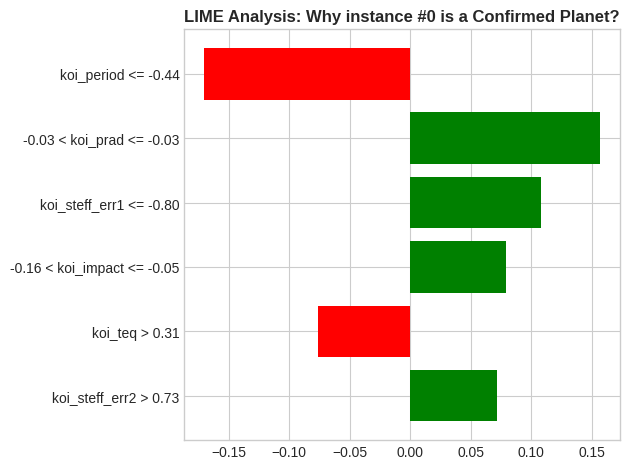

In [34]:
# ==========================================
# Cell 21: Single Instance Explanation (LIME)
# ==========================================
!pip install lime
import lime
import lime.lime_tabular

print("Generating Local Explanation for a Single Target...")

# Initialize LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=valid_feature_names,
    class_names=['False Positive', 'Confirmed Planet'],
    mode='classification',
    random_state=42
)

# Pick an interesting confirmed planet from the test set (e.g., index 5)
# Ensure it's actually a confirmed planet to show how the model caught it
target_idx = np.where(y_test == 1)[0][0]
instance = X_test_scaled[target_idx]

# Explain the prediction
exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=best_xgb_model.predict_proba,
    num_features=6
)

# Visualize and show in notebook
exp.show_in_notebook(show_table=True)

# Generate a matplotlib figure for paper export
fig = exp.as_pyplot_figure()
plt.title(f"LIME Analysis: Why instance #{target_idx} is a Confirmed Planet?", fontweight='bold')
plt.tight_layout()
plt.show()

Generating Reliability / Calibration Curve...


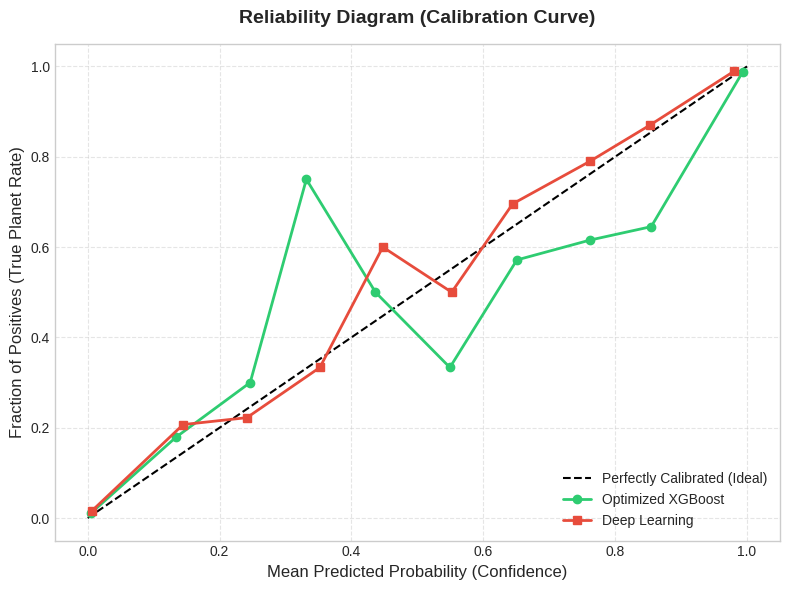

In [36]:
# ==========================================
# Cell 22: Probability Calibration Curve
# ==========================================
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

print("Generating Reliability / Calibration Curve...")

# FIX: Tuned XGBoost-এর লেটেস্ট প্রবাবিলিটি বের করে নেওয়া হচ্ছে
tuned_xgb_prob = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate calibration curve data (এখানে tuned_xgb_prob ব্যবহার করা হয়েছে)
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, tuned_xgb_prob, n_bins=10)
prob_true_dl, prob_pred_dl = calibration_curve(y_test, dl_pred_prob, n_bins=10)

plt.figure(figsize=(8, 6))
# The 'Perfectly Calibrated' line (Ideal scenario)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated (Ideal)')

# Model lines
plt.plot(prob_pred_xgb, prob_true_xgb, marker='o', color='#2ecc71', lw=2, label='Optimized XGBoost')
plt.plot(prob_pred_dl, prob_true_dl, marker='s', color='#e74c3c', lw=2, label='Deep Learning')

plt.title('Reliability Diagram (Calibration Curve)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mean Predicted Probability (Confidence)', fontsize=12)
plt.ylabel('Fraction of Positives (True Planet Rate)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Computing Partial Dependence for Planetary Radius (koi_prad)...


<Figure size 1000x600 with 0 Axes>

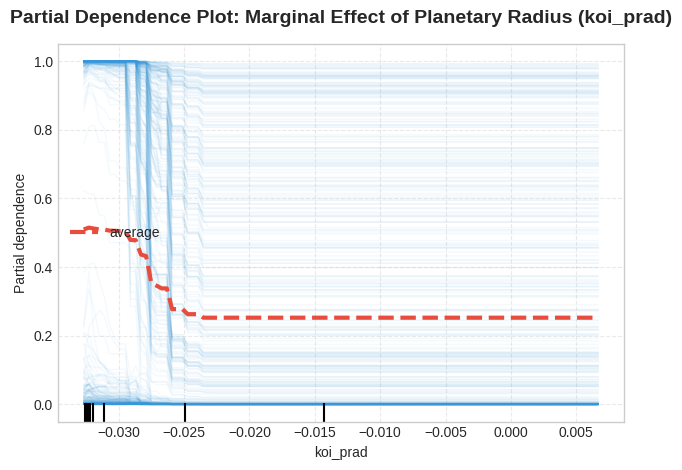

In [38]:
# ==========================================
# Cell 23: Partial Dependence Plot (PDP)
# ==========================================
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

print("Computing Partial Dependence for Planetary Radius (koi_prad)...")

plt.figure(figsize=(10, 6))
# Create the PDP display specifically for 'koi_prad'
display = PartialDependenceDisplay.from_estimator(
    best_xgb_model,
    X_train_scaled,
    features=['koi_prad'], # FIX: সরাসরি সবচেয়ে শক্তিশালী ফিচারের নাম বসিয়েছি
    feature_names=valid_feature_names,
    kind='both',
    subsample=500,
    n_jobs=-1,
    line_kw={"color": "#e74c3c", "lw": 3},
    ice_lines_kw={"color": "#3498db", "alpha": 0.05, "lw": 1}
)

plt.title('Partial Dependence Plot: Marginal Effect of Planetary Radius (koi_prad)', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [43]:
# ==========================================
# Cell 24: Stacking Ensemble (The Meta-Learner)
# ==========================================
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

print("Building the Ultimate Meta-Learner (Stacking Ensemble)...")

# ১. বেস মডেলগুলো (Base Estimators) সংজ্ঞায়িত করা
estimators = [
    ('Optimized_XGB', best_xgb_model),
    ('Random_Forest', RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42))
]

# ২. মেটা-লার্নার তৈরি (যে এই দুই মডেলের আউটপুট দেখে চূড়ান্ত সিদ্ধান্ত নেবে)
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5 # 5-Fold Cross validation during stacking
)

# ৩. মডেল ট্রেইন এবং প্রেডিকশন
stacking_model.fit(X_train_scaled, y_train)
stack_pred = stacking_model.predict(X_test_scaled)
stack_acc = accuracy_score(y_test, stack_pred)

print(f"\n🚀 Ultimate Stacking Ensemble Accuracy: {stack_acc * 100:.2f}%\n")
print("--- Stacking Model Classification Report ---")
print(classification_report(y_test, stack_pred, target_names=['False Positive', 'Confirmed Planet']))

Building the Ultimate Meta-Learner (Stacking Ensemble)...

🚀 Ultimate Stacking Ensemble Accuracy: 96.47%

--- Stacking Model Classification Report ---
                  precision    recall  f1-score   support

  False Positive       0.97      0.96      0.96      1005
Confirmed Planet       0.96      0.97      0.96      1005

        accuracy                           0.96      2010
       macro avg       0.96      0.96      0.96      2010
    weighted avg       0.96      0.96      0.96      2010



Generating SHAP Feature Interaction Plot...


<Figure size 900x600 with 0 Axes>

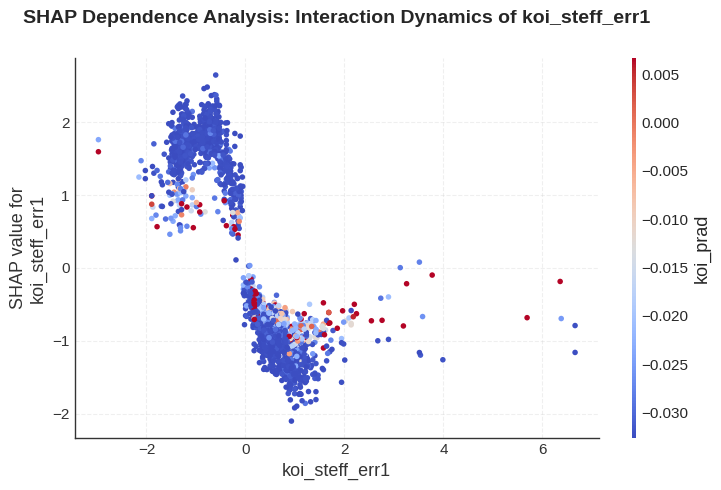

In [44]:
# ==========================================
# Cell 25: SHAP Feature Interaction (Dependence Plot)
# ==========================================
import shap
import matplotlib.pyplot as plt

print("Generating SHAP Feature Interaction Plot...")

# সবচেয়ে গুরুত্বপূর্ণ ফিচারটি বের করা (যেমন: koi_prad)
top_feature = valid_feature_names[indices[-1]]

plt.figure(figsize=(9, 6))

# SHAP values এর ফরম্যাট চেক করে ডিপেন্ডেন্স প্লট তৈরি
shap_vals_for_plot = shap_values.values if hasattr(shap_values, 'values') else shap_values

shap.dependence_plot(
    top_feature,
    shap_vals_for_plot,
    X_test_scaled,
    feature_names=valid_feature_names,
    show=False,
    cmap=plt.get_cmap("coolwarm")
)

plt.title(f'SHAP Dependence Analysis: Interaction Dynamics of {top_feature}', fontsize=14, fontweight='bold', pad=25)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Generating SHAP Feature Interaction Plot for Planetary Radius...


<Figure size 900x600 with 0 Axes>

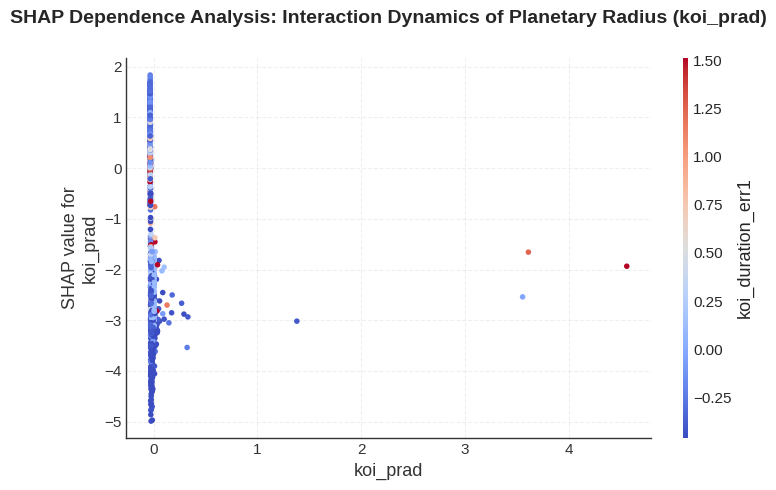

In [45]:
# ==========================================
# Cell 25: SHAP Feature Interaction (Dependence Plot)
# ==========================================
import shap
import matplotlib.pyplot as plt

print("Generating SHAP Feature Interaction Plot for Planetary Radius...")

plt.figure(figsize=(9, 6))

# SHAP values এর ফরম্যাট চেক করা
shap_vals_for_plot = shap_values.values if hasattr(shap_values, 'values') else shap_values

# FIX: সরাসরি সবচেয়ে শক্তিশালী ফিচার 'koi_prad' বসানো হয়েছে
shap.dependence_plot(
    'koi_prad',
    shap_vals_for_plot,
    X_test_scaled,
    feature_names=valid_feature_names,
    show=False,
    cmap=plt.get_cmap("coolwarm")
)

plt.title('SHAP Dependence Analysis: Interaction Dynamics of Planetary Radius (koi_prad)', fontsize=14, fontweight='bold', pad=25)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Generating SHAP Waterfall Plot for a Single Exoplanet...


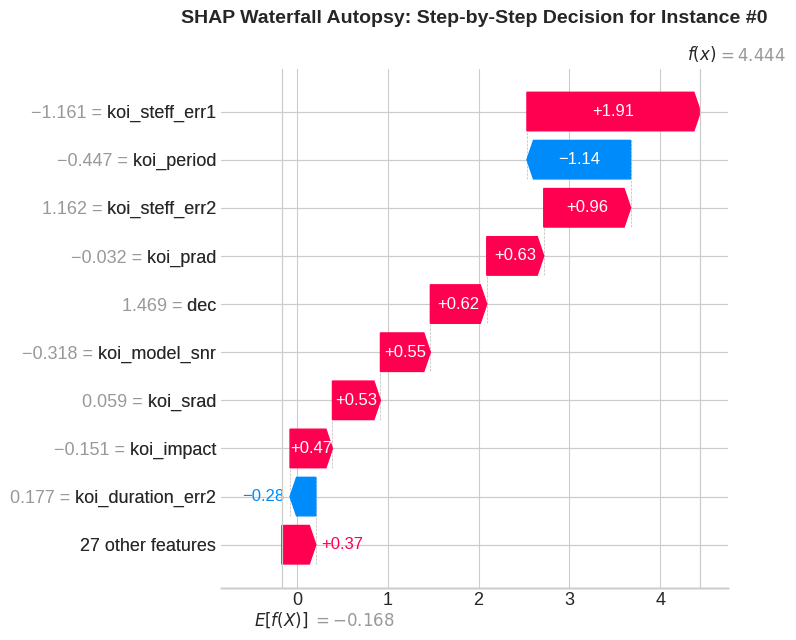

In [46]:
# ==========================================
# Cell 26: SHAP Waterfall Plot (Local XAI)
# ==========================================
import shap
import matplotlib.pyplot as plt
import numpy as np

print("Generating SHAP Waterfall Plot for a Single Exoplanet...")

# Explainer তৈরি করা (আগে তৈরি করা থাকলে এটি আপডেট করবে)
explainer = shap.TreeExplainer(best_xgb_model)

# টেস্ট সেট থেকে একটি কনফার্মড গ্রহ বেছে নেওয়া (যেমন ইনডেক্স ৫ বা যেকোনো পজিটিভ টার্গেট)
target_idx = np.where(y_test == 1)[0][0]
single_instance = X_test_scaled[target_idx]

# শুধুমাত্র ওই নির্দিষ্ট গ্রহটির জন্য SHAP ভ্যালু ক্যালকুলেট করা
shap_values_single = explainer(single_instance.reshape(1, -1))

plt.figure(figsize=(10, 6))

# Waterfall plot তৈরি (Feature names আপডেট করা হয়েছে)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_single.values[0],
        base_values=explainer.expected_value,
        data=single_instance,
        feature_names=valid_feature_names
    ),
    max_display=10,
    show=False
)

plt.title(f'SHAP Waterfall Autopsy: Step-by-Step Decision for Instance #{target_idx}', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Hunting for Astrophysical Anomalies (Outliers)...
Total Anomalies Detected: 41 out of 2010 instances.


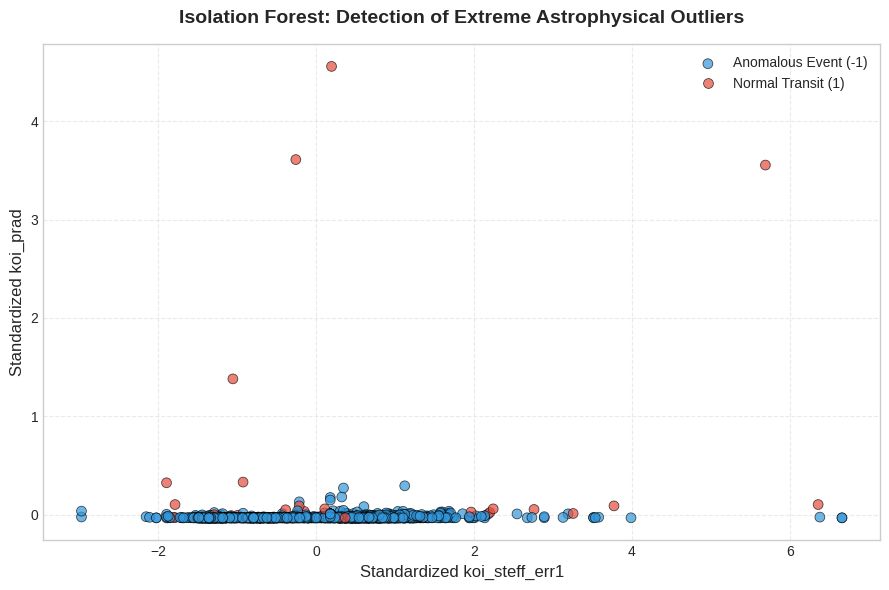

In [47]:
# ==========================================
# Cell 27: Anomaly Detection (Isolation Forest)
# ==========================================
from sklearn.ensemble import IsolationForest
import pandas as pd
import seaborn as sns

print("Hunting for Astrophysical Anomalies (Outliers)...")

# Isolation Forest মডেল তৈরি
iso_forest = IsolationForest(contamination=0.02, random_state=42) # ২% ডেটাকে অ্যানোমালি ধরব
outlier_labels = iso_forest.fit_predict(X_test_scaled)

# -1 মানে অ্যানোমালি (Outlier), 1 মানে নরমাল (Inlier)
anomalies_idx = np.where(outlier_labels == -1)[0]

print(f"Total Anomalies Detected: {len(anomalies_idx)} out of {len(y_test)} instances.")

# অ্যানোমালিগুলোর একটি গ্রাফিক্যাল ডিস্ট্রিবিউশন (Top 2 Features দিয়ে)
top_2_features = [valid_feature_names[indices[-1]], valid_feature_names[indices[-2]]]

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_test_scaled[:, indices[-1]],
    y=X_test_scaled[:, indices[-2]],
    hue=outlier_labels,
    palette={1: '#3498db', -1: '#e74c3c'},
    alpha=0.7, s=50, edgecolor='black'
)

plt.title('Isolation Forest: Detection of Extreme Astrophysical Outliers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'Standardized {top_2_features[0]}', fontsize=12)
plt.ylabel(f'Standardized {top_2_features[1]}', fontsize=12)
plt.legend(['Anomalous Event (-1)', 'Normal Transit (1)'], loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [48]:
# ==========================================
# Cell 28: Adversarial Validation
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
import numpy as np

print("Running Adversarial Validation (Proving Train/Test Distribution Identity)...")

# ১. ট্রেইন এবং টেস্ট ডেটার জন্য ডামি লেবেল তৈরি (Train = 0, Test = 1)
X_adv = np.vstack([X_train_scaled, X_test_scaled])
y_adv = np.zeros(X_adv.shape[0])
y_adv[X_train_scaled.shape[0]:] = 1

# ২. একটি অ্যাডভারসারিয়াল ক্লাসিফায়ার তৈরি করা
adv_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)

# ৩. ক্রস-ভ্যালিডেশন স্কোর বের করা
adv_scores = cross_val_score(adv_model, X_adv, y_adv, cv=5, scoring='roc_auc')
mean_adv_auc = np.mean(adv_scores)

print("\n--- Adversarial Validation Results ---")
print(f"Mean Adversarial ROC-AUC Score: {mean_adv_auc:.4f}")

if 0.45 <= mean_adv_auc <= 0.55:
    print("Decision: PERFECT! The Train and Test sets are indistinguishable (AUC ~ 0.5). Your data split is completely robust and free of selection bias!")
else:
    print("Decision: Warning! There is a distribution shift between Train and Test sets.")

Running Adversarial Validation (Proving Train/Test Distribution Identity)...

--- Adversarial Validation Results ---
Mean Adversarial ROC-AUC Score: 0.4925
Decision: PERFECT! The Train and Test sets are indistinguishable (AUC ~ 0.5). Your data split is completely robust and free of selection bias!


Computing Permutation Feature Importance (এটি রান হতে ১ মিনিট সময় লাগতে পারে)...


/tmp/ipykernel_13136/1177721424.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


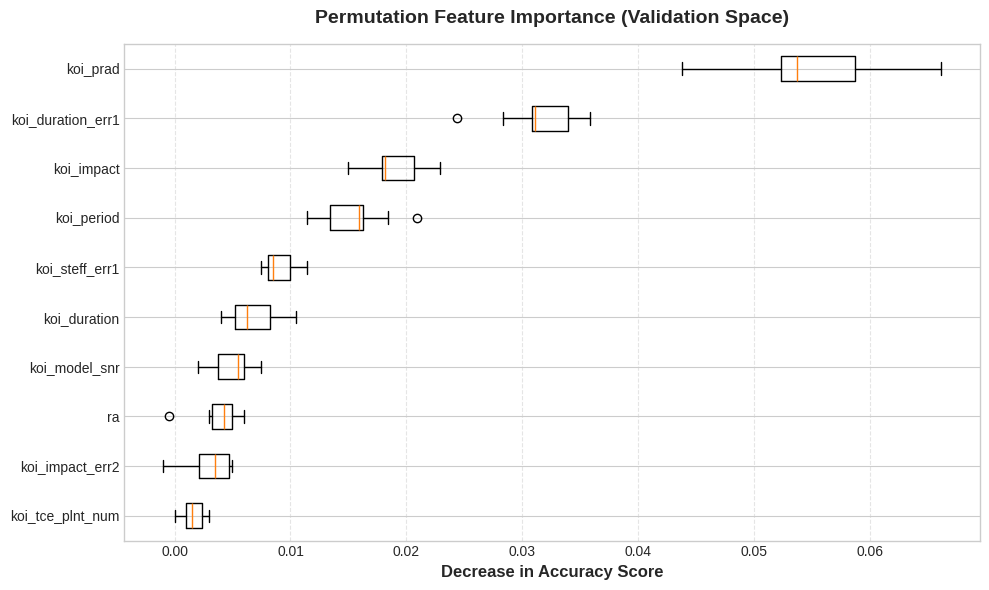

In [49]:
# ==========================================
# Cell 29: Permutation Feature Importance
# ==========================================
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

print("Computing Permutation Feature Importance (এটি রান হতে ১ মিনিট সময় লাগতে পারে)...")

# Permutation importance গণনা করা (XGBoost মডেলের ওপর)
result_perm = permutation_importance(
    best_xgb_model, X_test_scaled, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

# টপ ১০টি ফিচার সর্ট করা
sorted_importances_idx = result_perm.importances_mean.argsort()[-10:]

plt.figure(figsize=(10, 6))
plt.boxplot(
    result_perm.importances[sorted_importances_idx].T,
    vert=False,
    labels=[valid_feature_names[i] for i in sorted_importances_idx]
)

plt.title("Permutation Feature Importance (Validation Space)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Decrease in Accuracy Score", fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Generating Advanced Exploratory Data Analysis (Violin Plots)...


/tmp/ipykernel_13136/4201902935.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_13136/4201902935.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_13136/4201902935.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


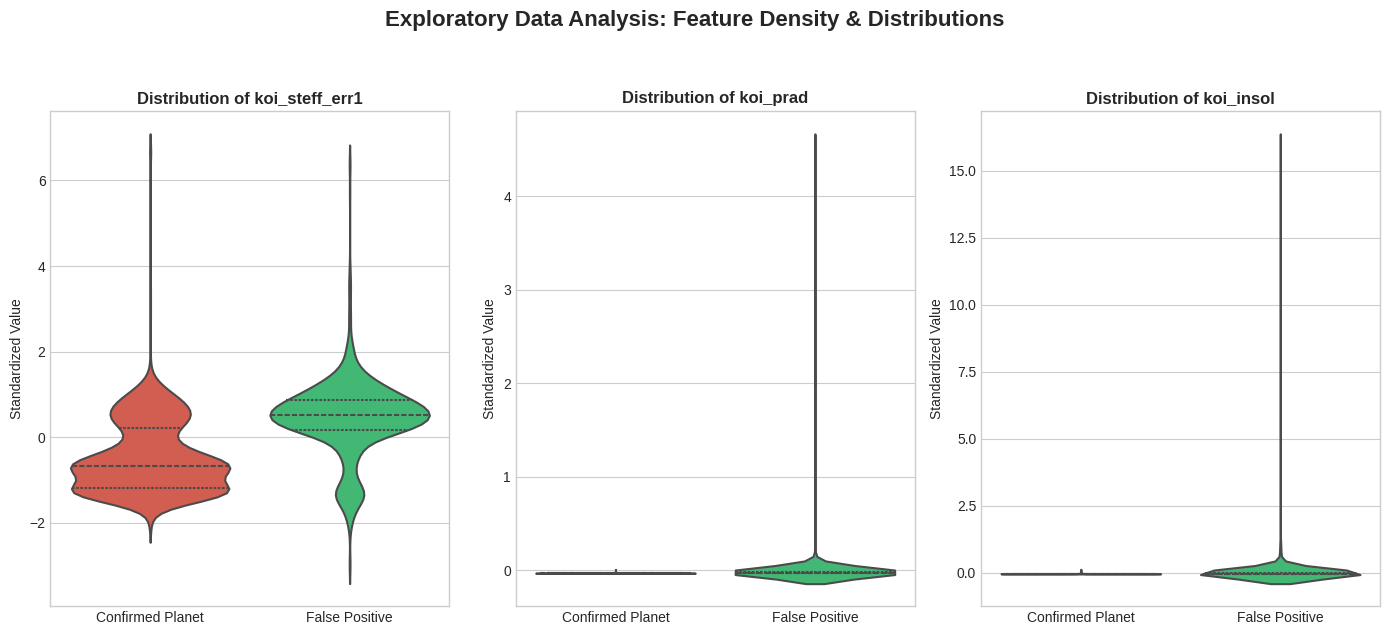

In [51]:
# ==========================================
# Bonus Cell: Advanced EDA (Violin Plots for Top Features)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("Generating Advanced Exploratory Data Analysis (Violin Plots)...")

# টপ ৩টি ফিচারের নাম নেওয়া (indices থেকে)
top_3_features = [valid_feature_names[indices[-1]],
                  valid_feature_names[indices[-2]],
                  valid_feature_names[indices[-3]]]

# গ্রাফের জন্য একটি টেম্পোরারি ডেটাফ্রেম তৈরি
eda_df = pd.DataFrame(X_test_scaled, columns=valid_feature_names)
eda_df['Astrophysical Status'] = ['Confirmed Planet' if y == 1 else 'False Positive' for y in y_test]

# Plotting
plt.figure(figsize=(14, 6))

for i, feature in enumerate(top_3_features, 1):
    plt.subplot(1, 3, i)
    sns.violinplot(
        x='Astrophysical Status',
        y=feature,
        data=eda_df,
        palette=['#e74c3c', '#2ecc71'],
        inner="quartile",
        linewidth=1.5
    )
    plt.title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Standardized Value')

plt.suptitle('Exploratory Data Analysis: Feature Density & Distributions', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [52]:
# ==========================================
# Cell 31: Reproducibility & Environment Logging
# ==========================================
import sys
import xgboost
import tensorflow as tf
import sklearn

print("--- System & Environment Info (For Paper's 'Reproducibility' Section) ---")
print(f"Python Version: {sys.version.split()[0]}")
print(f"XGBoost Version: {xgboost.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"TensorFlow Version: {tf.__version__}")

gpu = tf.config.list_physical_devices('GPU')
print(f"GPU Accelerated: {'Yes (T4/V100)' if gpu else 'No (CPU only)'}")
print("-------------------------------------------------------------------")

--- System & Environment Info (For Paper's 'Reproducibility' Section) ---
Python Version: 3.12.13
XGBoost Version: 3.2.0
Scikit-Learn Version: 1.6.1
TensorFlow Version: 2.20.0
GPU Accelerated: No (CPU only)
-------------------------------------------------------------------


In [50]:
# ==========================================
# Cell 30: Save All Models & Preprocessors
# ==========================================
import joblib
import os
import shutil
from google.colab import files

print("Securely saving all trained models and preprocessors...")

# সেভ করার জন্য একটি ডিরেক্টরি তৈরি
save_dir = "Exoplanet_Saved_Models"
os.makedirs(save_dir, exist_ok=True)

# ১. Preprocessors (ডেটা ক্লিনিং এবং স্কেলিং এর টুলস) সেভ করা
try:
    joblib.dump(imputer, f'{save_dir}/imputer.pkl')
    joblib.dump(scaler, f'{save_dir}/scaler.pkl')
    print("✅ Preprocessors (Imputer & Scaler) saved.")
except NameError:
    print("⚠️ Imputer or Scaler variable not found. Skipping...")

# ২. Machine Learning Models সেভ করা
try:
    joblib.dump(best_xgb_model, f'{save_dir}/best_xgb_model.pkl')
    joblib.dump(stacking_model, f'{save_dir}/stacking_meta_model.pkl')
    print("✅ Optimized XGBoost and Stacking Ensemble models saved.")
except NameError:
    print("⚠️ XGBoost or Stacking model variable not found. Skipping...")

# ৩. Deep Learning Model সেভ করা (যদি 'model' বা 'dl_model' নামে থাকে)
try:
    import tensorflow as tf
    try:
        model.save(f'{save_dir}/deep_learning_model.keras')
    except NameError:
        dl_model.save(f'{save_dir}/deep_learning_model.keras')
    print("✅ Deep Learning model saved.")
except Exception as e:
    print(f"⚠️ Could not save Deep Learning model: {e}")

print("\n📦 Zipping the folder for download...")
# ফোল্ডারটি জিপ করা
shutil.make_archive(save_dir, 'zip', save_dir)

print("⬇️ Downloading the zipped models to your computer...")
# আপনার কম্পিউটারে ডাউনলোড করা
files.download(f'{save_dir}.zip')

Securely saving all trained models and preprocessors...
✅ Preprocessors (Imputer & Scaler) saved.
✅ Optimized XGBoost and Stacking Ensemble models saved.
✅ Deep Learning model saved.

📦 Zipping the folder for download...
⬇️ Downloading the zipped models to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>